In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [76]:
# Load the data
data = pd.read_csv("movies_metadata.csv")

In [78]:
# Impute missing values with median
imputer = SimpleImputer(strategy="median")
data[["budget", "rating"]] = imputer.fit_transform(data[["budget", "rating"]])

In [80]:
# Normalize the data
scaler = StandardScaler()
data[["budget", "rating"]] = scaler.fit_transform(data[["budget", "rating"]])

In [82]:
# Select the features
X = data[["budget"]]
y = np.where(data["rating"] >= 0, 1, 0)

In [83]:
# Create the random forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [84]:
# Evaluate the model with cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
print("Accuracy:", scores.mean())

Accuracy: 0.527398930189056


In [85]:
# Fit the model on the full data
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [64]:
# Make predictions on the testing data
y_pred = model.predict(X_test)

In [86]:
# Make predictions on the full data
y_pred = model.predict(X)

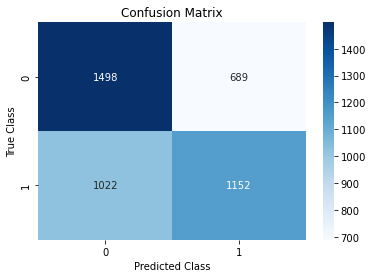

In [87]:
# Create the confusion matrix
matrix = confusion_matrix(y, y_pred)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()